# Indlæsning af data via dataloader

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Importerer din nye dataloader. 
# Bemærk: Den vil bruge lidt tid på at downloade data fra GitHub første gang den køres.
import dataloader

# Hent den rensede og kategoriserede dataframe fra dataloaderen
samlet_df = dataloader.samlet_df

print(f"Data er indlæst via dataloader. Antal rækker: {len(samlet_df)}")

Data er indlæst via dataloader. Antal rækker: 233980


# Violinplots for de N mest populære kategorier

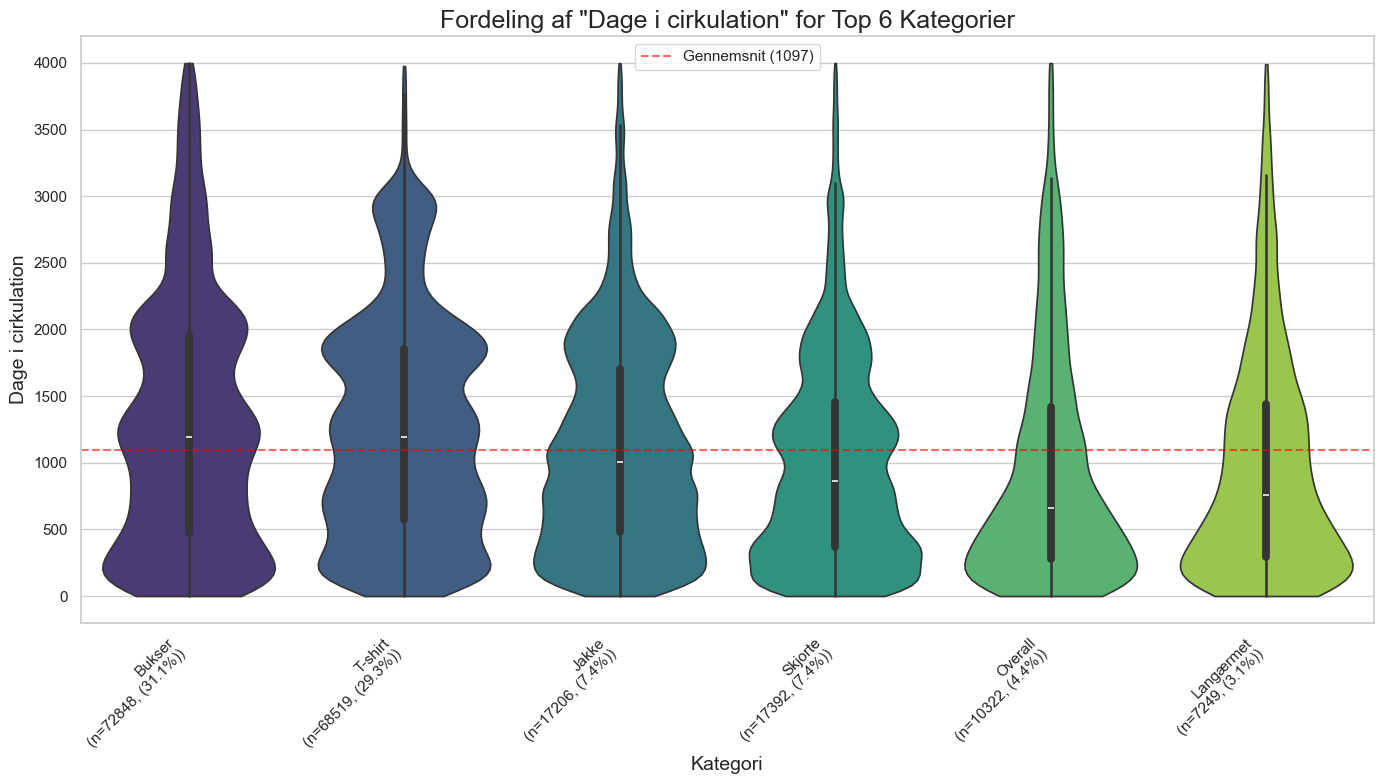

In [27]:
# Antal kategorier i plottet
N = 6 

# Muligheder: 'Dage i cirkulation'  ELLER  'Total antal vask' ELLER 'Vask per måned'
y_akse_navn = 'Dage i cirkulation'

# Sikre at kolonnerne er tal
cols_to_numeric = ['Dage i cirkulation', 'Total antal vask', 'Vask per måned']
for col in cols_to_numeric:
    samlet_df[col] = pd.to_numeric(samlet_df[col], errors='coerce')

# Find de N mest populære kategorier
top_kategorier = samlet_df['Kategori'].value_counts().head(N).index
df_plot = samlet_df[samlet_df['Kategori'].isin(top_kategorier)]

# Fjern ekstreme outliers for pænere graf
if y_akse_navn == 'Dage i cirkulation':
    grænse = 4000 # Fjern alt over ca 11 år
elif y_akse_navn == 'Total antal vask':
    grænse = 300  # Fjern alt over 300 vaske
else:
    grænse = df_plot[y_akse_navn].max()
    
df_plot = df_plot[df_plot[y_akse_navn] < grænse]

# liste af labels i samme rækkefølge som plottet - bruges til at plotte antal ved hver kategori
nye_labels = []
total_data_count = len(samlet_df) # Bruges til at beregne procent af hele datasættet
for kat in top_kategorier:
    antal = len(df_plot[df_plot['Kategori'] == kat])
    procent = (antal / total_data_count) * 100
    label = f"{kat}\n(n={antal}, ({procent:.1f}%))"
    nye_labels.append(label)

# PLOTTET
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=df_plot, 
    x='Kategori', 
    y=y_akse_navn, 
    hue='Kategori',         # Tilføjet for at fjerne warning
    palette="viridis", 
    cut=0,          # Skærer grafen af ved min/max data
    density_norm='width',   # Gør alle violiner lige brede for nem sammenligning
    legend=False            # Tilføjet for at fjerne warning
)

plt.title(f'Fordeling af "{y_akse_navn}" for Top {N} Kategorier', fontsize=18)
plt.xlabel('Kategori', fontsize=14)
plt.ylabel(y_akse_navn, fontsize=14)
plt.xticks(rotation=45, ha='right')

# Tilføj gennemsnitslinje
snit = df_plot[y_akse_navn].mean()
plt.axhline(snit, color='red', linestyle='--', alpha=0.6, label=f'Gennemsnit ({int(snit)})')
plt.legend()

plt.xticks(ticks=range(len(top_kategorier)), labels=nye_labels, rotation=45) # plot antal

plt.tight_layout()
plt.show()

# Violionplots over kassationsårsager for en bestemt kategori

In [28]:
# du kan stadig skifte mellem 'Dage i cirkulation' og 'Total antal vask' på y-akse
def lav_plot(kategori, data, y_akse='Dage i cirkulation', N=6):
    
    # Filtrer på den valgte kategori (bruger argumentet 'kategori')
    df_kat = data[data['Kategori'] == kategori]
    
    # Tjek om der overhovedet er data (hvis nu man staver forkert)
    if len(df_kat) == 0:
        print(f"Advarsel: Ingen data fundet for '{kategori}'")
        return

    total_kat_antal = len(df_kat) 

    # Find top årsager
    top_årsager = df_kat['Kassationsårsag (ui)'].value_counts().head(N).index
    df_plot = df_kat[df_kat['Kassationsårsag (ui)'].isin(top_årsager)]

    # Fjern outliers
    limit = 4000 if y_akse == 'Dage i cirkulation' else 300
    df_plot = df_plot[df_plot[y_akse] < limit]

    # Lav labels
    nye_labels = []
    for aarsag in top_årsager:
        antal = len(df_plot[df_plot['Kassationsårsag (ui)'] == aarsag])
        procent = (antal / total_kat_antal) * 100
        
        # Kort teksten af
        kort_tekst = (aarsag[:20] + '..') if len(aarsag) > 20 else aarsag
        
        # Din formatering
        label = f"{kort_tekst}\n(n={antal}, ({procent:.1f}%))"
        nye_labels.append(label)

    # --- PLOT ---
    plt.figure(figsize=(15, 8))
    sns.violinplot(
        data=df_plot, 
        x='Kassationsårsag (ui)', 
        y=y_akse, 
        order=top_årsager, 
        hue='Kassationsårsag (ui)', # Tilføjet for at fjerne warning
        palette="viridis", 
        cut=0,
        density_norm='width',
        legend=False                # Tilføjet for at fjerne warning
    )

    plt.title(f'Top {N} Kassationsårsager for "{kategori}", (n = {total_kat_antal})', fontsize=18)
    plt.ylabel(y_akse, fontsize=14)
    plt.xlabel('Årsag (Andel af kategorien)', fontsize=14)

    snit = df_plot[y_akse].mean()
    plt.axhline(snit, color='red', linestyle='--', alpha=0.7, label=f'Gennemsnit ({int(snit)})')

    plt.xticks(ticks=range(len(top_årsager)), labels=nye_labels, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    
    # Vis plottet
    plt.show()

# Violinplots for mange kategorier

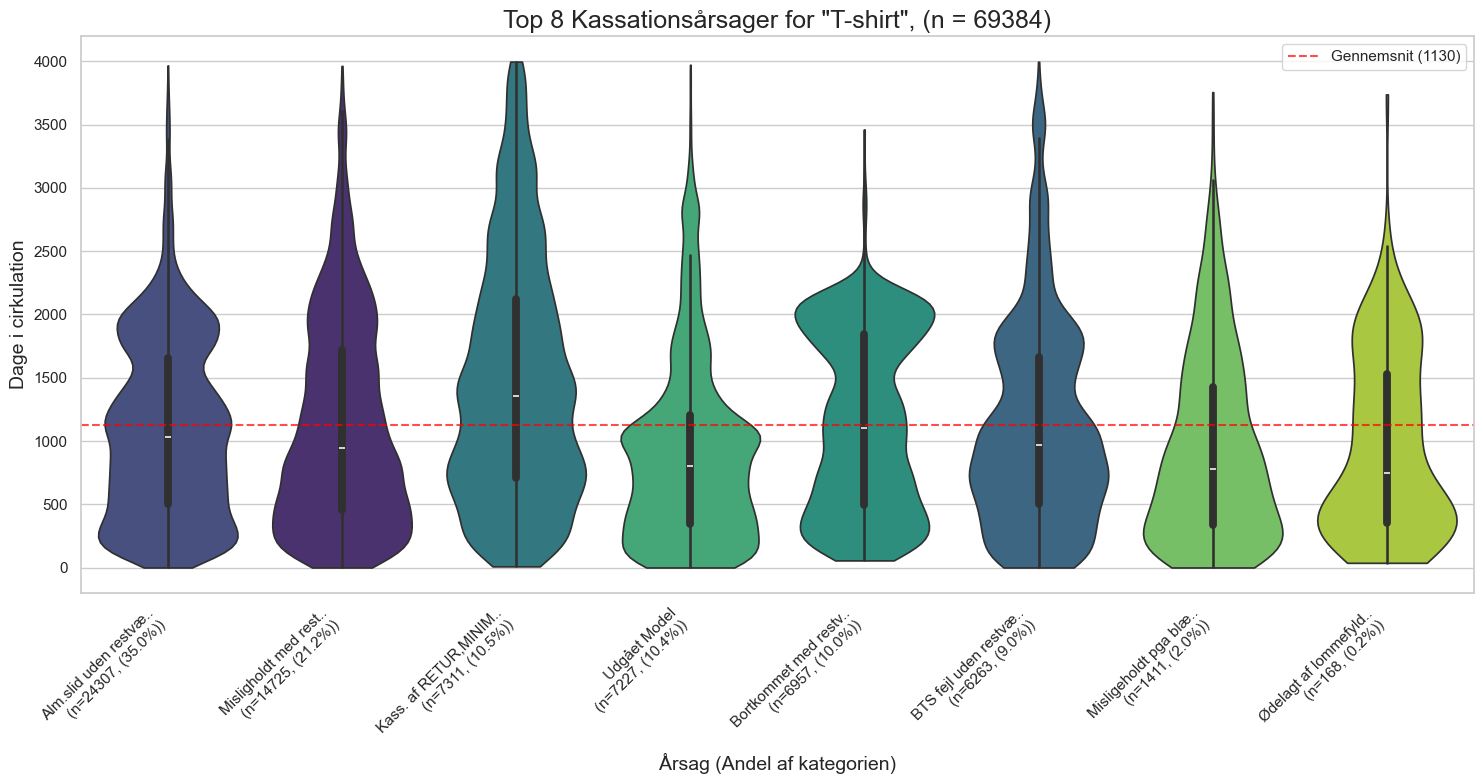

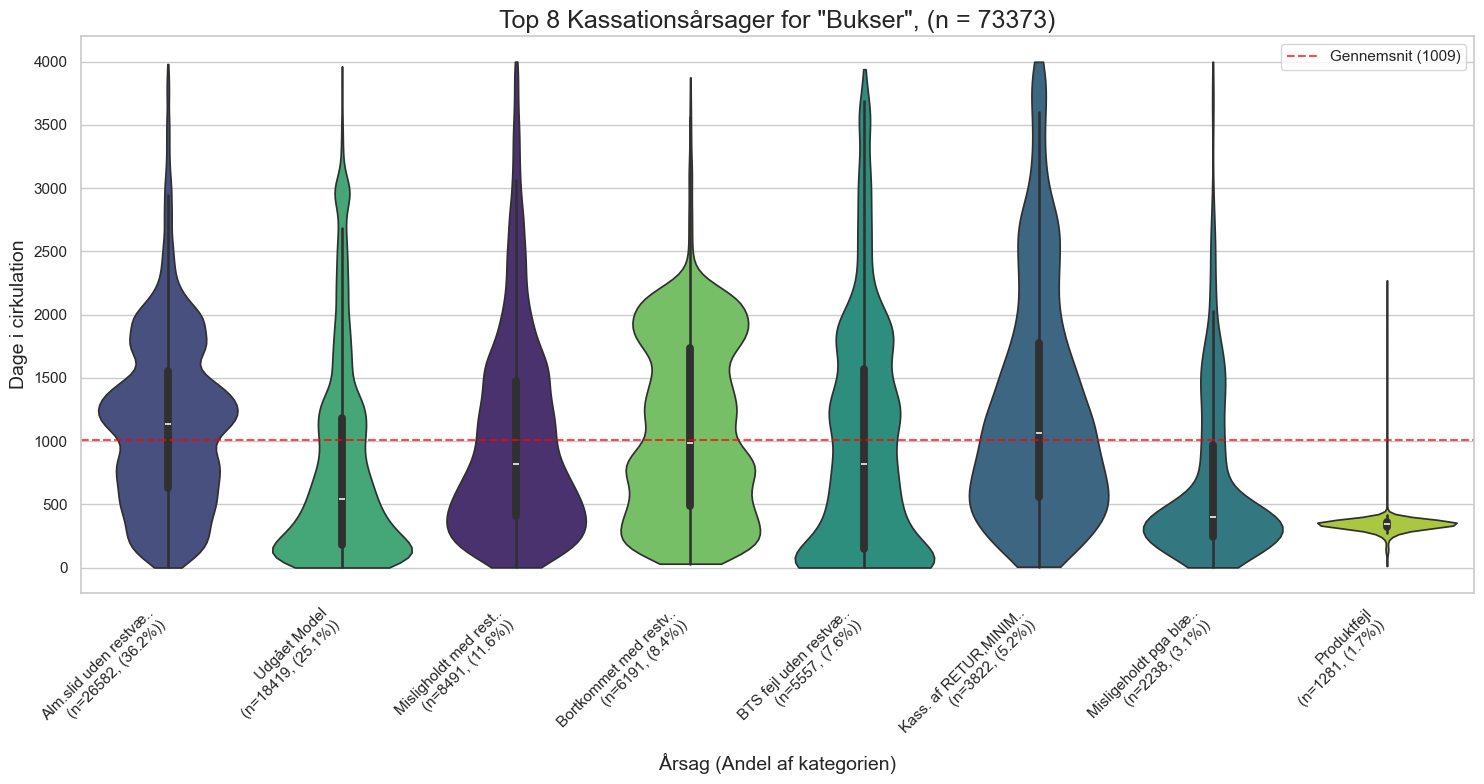

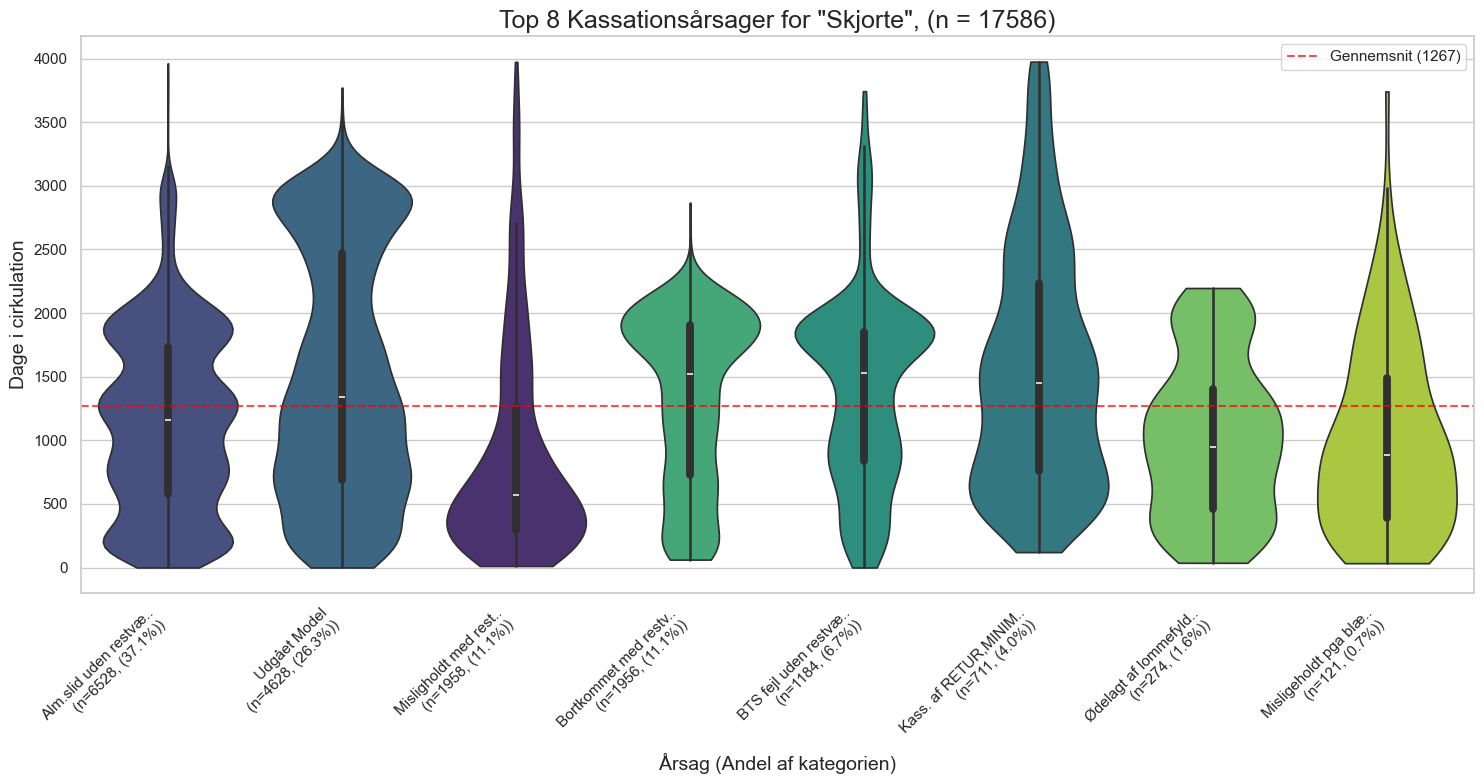

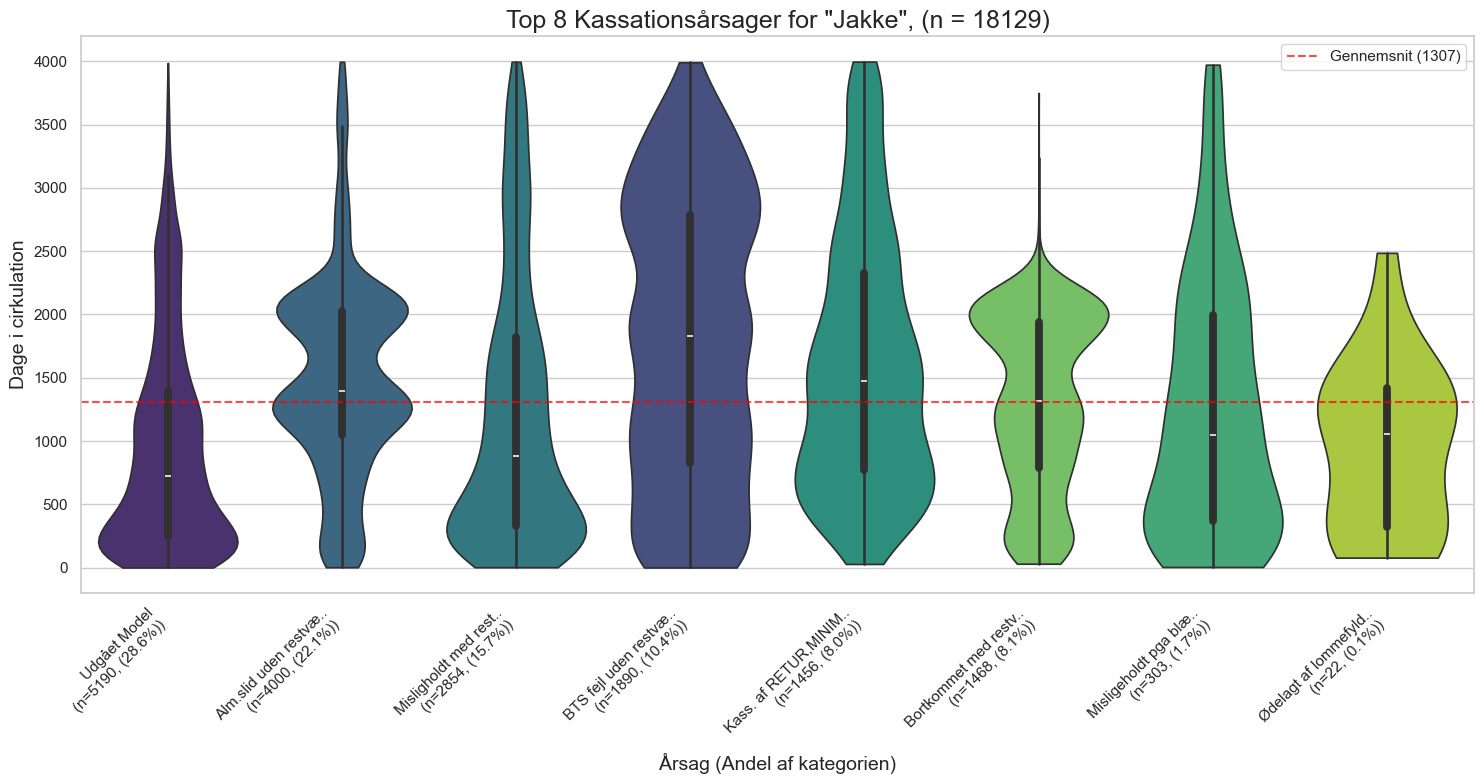

In [ ]:
# Liste over kategorier 
mine_kategorier = ['T-shirt', 'Bukser', 'Skjorte', 'Jakke']


for kat in mine_kategorier:
    lav_plot(kat, samlet_df, y_akse='Dage i cirkulation', N=8)

# y_akse='Dage i cirkulation' eller y_akse='Total antal vask'